In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
def get_third_harmonic_bin(i, nfft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % nfft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > nfft // 2:
        harmonic_bin = nfft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [31]:
df = pd.read_csv('./xschem/simulation/tb_th_nmos_bulk.txt', sep='\\s+')
df

,time,v(vop)
0,3.500000e-09,0.341650
1,5.500000e-09,0.377921
2,7.500000e-09,0.410580
3,9.500000e-09,0.438395
4,1.150000e-08,0.460318
...,...,...
520,6.350000e-08,0.085378
521,6.550000e-08,0.478735
522,6.750000e-08,0.089660
523,6.950000e-08,0.453558


In [32]:
# Parameters
nfft = 32
pad = 3
bins = np.arange(1, nfft//2)
n = nfft + pad
v = np.reshape(df['v(vop)'].values, [len(df)//n, n])

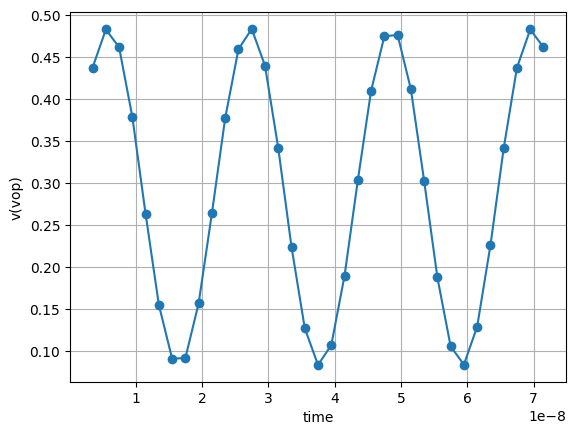

In [33]:
# Example plot
bin = 3
t = df['time']
t = t[0:n]
y = v[bin-1, :]
plt.plot(t, y, "-o")
plt.grid()
plt.ylabel("v(vop)")
plt.xlabel("time")
plt.show()

In [34]:
# Remove last point since it's off the sampling grid
y = y[:-1]
print(len(y))

# Check periodicity/steady state by comparing the last valid sample of the FFT window with one right before the window
relative_error = (y[-1]-y[-1-nfft])/y[-1]
print(relative_error)

34
-1.0785848740705762e-06


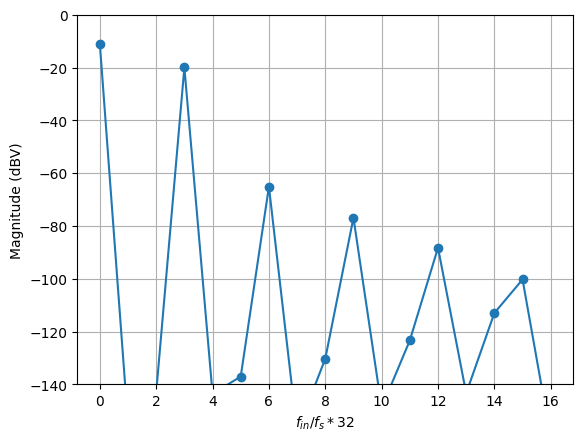

In [35]:
# Example spectrum
y = y[-nfft:]
spec = np.fft.rfft(y)
spec_dbv = 20*np.log10(np.abs(spec)/(nfft))
plt.plot(spec_dbv, "-o")
plt.grid()
plt.xlabel("$f_{in}/f_s*32$")
plt.ylabel("Magnitude (dBV)")
plt.ylim([-140, 0])
plt.show()

In [36]:
# SFDR and HD3 for all input frequencies
sfdr = np.zeros(len(bins))
hd3 = np.zeros(len(bins))
for i in bins:
    y = v[i-1, :]
    y = y[:-1]
    y = y[-nfft:]
    spec = np.fft.rfft(y)
    spec_dbv = 20*np.log10(np.abs(spec)/(nfft))
    sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
    hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, nfft)]

# remove bin 7 data since it has distortion aliases on top of signal
sfdr = np.delete(sfdr, [7])
hd3 = np.delete(hd3, [7])
bins = np.delete(bins, [7])

# save for plotting
np.savez('pp_tb_th_nmos_bulk.npz', sfdr=sfdr, hd3=hd3, bins=bins)
